# Xây dựng mô hình Baseline

**Mục tiêu:**
- Thực hiện các bước xây dựng mô hình cơ sở nhằm tối ưu luồng pineline, đồng thời xây dựng các hàm hỗ trợ
- Xây dựng hàm đánh giá chỉ số mô hình theo tiêu chí `ISO/SEC 30107`
- Xác định mục tiêu và hướng đi cho toàn bộ dự án
- Sử dụng mô hình cơ sở để đánh giá thêm một vài phương pháp huấn luyện mô hình khác được kiểm tra trong notebooks [03_Optimize.ipynb](./03_Optimize.ipynb)

In [1]:
import os
import sys
import numpy as np

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomBrightness, RandomContrast, RandomTranslation
from keras.optimizers import Adam
from keras.utils import image_dataset_from_directory, set_random_seed
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

sys.path.append(os.path.abspath('..'))
from models.BaselineModel import baseline_model
from src.evaluate import MetricsCallback, plot_training_history, evaluate_model

I0000 00:00:1791541742.765950  448869 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791541742.970217  448869 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791541748.103870  448869 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
IMG_SIZE = 224
EPOCHS = 5
BATCH_SIZE = 32
SEED = 42
OUTPUT_DIR = '../outputs/baseline-model'
CACHE = '../cache/baseline-model'

set_random_seed(SEED)

# Xóa cache cũ để tránh lỗi (nếu có)
import shutil
if os.path.exists(CACHE):
    shutil.rmtree(CACHE)
os.makedirs(CACHE, exist_ok=True)


## 1. Chuẩn bị dữ liệu

---

In [3]:
train_dir = '../datasets/LCC_FASD/train'
val_dir = '../datasets/LCC_FASD/val'
test_dir = '../datasets/LCC_FASD/test'

print("Tập Train:")
train_ds = image_dataset_from_directory(
    train_dir, 
    image_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

print("\nTập Validation:")
val_ds = image_dataset_from_directory(
    val_dir, 
    image_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=False,
)

print("\nTập Test:")
test_ds = image_dataset_from_directory(
    test_dir, 
    image_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=False,
)


Tập Train:
Found 8223 files belonging to 2 classes.


E0000 00:00:1791541753.040886  448869 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Tập Validation:
Found 2934 files belonging to 2 classes.

Tập Test:
Found 7531 files belonging to 2 classes.


In [4]:
train_aug = Sequential([                # Chuẩn hóa pixel
    RandomFlip("horizontal"),           # Lật ngang
    RandomRotation(0.05),               # Xoay ngẫu nhiên 5%
    RandomZoom(0.2),                    # Thu phóng 20%
    RandomBrightness(0.2),              # Thay đổi độ sáng 20%
    RandomContrast(0.2),                # Thay đổi tương phản 20%
    RandomTranslation(0.01, 0.01),      # Dịch chuyển 1%
    Rescaling(1./255)                   # Chuẩn hóa pixel
])

val_aug = Sequential([Rescaling(1./255)]) # Chuẩn hóa pixel cho tập validation

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache(CACHE + '/train_cache')
train_ds = train_ds.map(lambda x, y: (train_aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache(CACHE + '/val_cache')
val_ds = val_ds.map(lambda x, y: (val_aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.cache(CACHE + '/test_cache')
test_ds = test_ds.map(lambda x, y: (val_aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


## 2. Xây dựng mô hình

---

In [5]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)

model = baseline_model(input_shape=input_shape, num_classes=1)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,795,169 (10.66 MB)

 Trainable params: 2,795,169 (10.66 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
metrics_callback = MetricsCallback(val_dataset=val_ds, threshold_path=OUTPUT_DIR + '/best_threshold.txt')

callbacks = [
    metrics_callback,

    ModelCheckpoint(
        filepath=OUTPUT_DIR + '/best_model.keras', 
        monitor='val_acer', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    ),

    EarlyStopping(
        monitor='val_acer',
        patience=5,
        mode='min',
        verbose=1,
        restore_best_weights=True
    )
]

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

W0000 00:00:1791541761.043332  448869 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. Huấn luyện mô hình

---

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    shuffle=False
)

Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8513 - loss: 0.3714 - APCER: 30.53% - BPCER: 30.37% - EER: 30.45% - ACER: 30.45% (t*: 0.7275) ⭐ NEW BEST

Epoch 1: val_acer improved from None to 0.30448, saving model to ../outputs/baseline-model/best_model.keras

Epoch 1: finished saving model to ../outputs/baseline-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 97s 357ms/step - accuracy: 0.8513 - loss: 0.3714 - val_accuracy: 0.8609 - val_loss: 0.3724 - val_apcer: 0.3053 - val_bpcer: 0.3037 - val_eer: 0.3045 - val_acer: 0.3045
Epoch 2/5


W0000 00:00:1791541858.138953  448869 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.8616 - loss: 0.3291 - APCER: 27.64% - BPCER: 27.41% - EER: 27.52% - ACER: 27.52% (t*: 0.8404) ⭐ NEW BEST

Epoch 2: val_acer improved from 0.30448 to 0.27523, saving model to ../outputs/baseline-model/best_model.keras

Epoch 2: finished saving model to ../outputs/baseline-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 89s 345ms/step - accuracy: 0.8616 - loss: 0.3291 - val_accuracy: 0.8429 - val_loss: 0.3912 - val_apcer: 0.2764 - val_bpcer: 0.2741 - val_eer: 0.2752 - val_acer: 0.2752
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.8711 - loss: 0.3118 - APCER: 28.39% - BPCER: 28.40% - EER: 28.39% - ACER: 28.39% (t*: 0.7533) 

Epoch 3: val_acer did not improve from 0.27523
257/257 ━━━━━━━━━━━━━━━━━━━━ 85s 328ms/step - accuracy: 0.8711 - loss: 0.3118 - val_accuracy: 0.8344 - val_loss: 0.3999 - val_apcer: 0.2839 - val_bpcer: 0.2840 - val_eer: 0.2839 - val_acer: 0.2839
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 27

## 4. Đánh giá toàn diện Mô hình (Dashboard)

---

In [8]:
threshold_best = metrics_callback.best_threshold
print(f"Ngưỡng tốt nhất: {threshold_best}")

y_prob = model.predict(test_ds)
y_pred = (y_prob >= threshold_best).astype(int).flatten()

y_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in test_ds], axis=0).flatten()

print(classification_report(y_true, y_pred))

Ngưỡng tốt nhất: 0.7004401683807373
236/236 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step


W0000 00:00:1791542232.005279  448869 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


              precision    recall  f1-score   support

         0.0       0.11      0.63      0.19       314
         1.0       0.98      0.78      0.87      7217

    accuracy                           0.77      7531
   macro avg       0.55      0.71      0.53      7531
weighted avg       0.94      0.77      0.84      7531



Đã lưu biểu đồ lịch sử tại: ../outputs/baseline-model/training_history.png


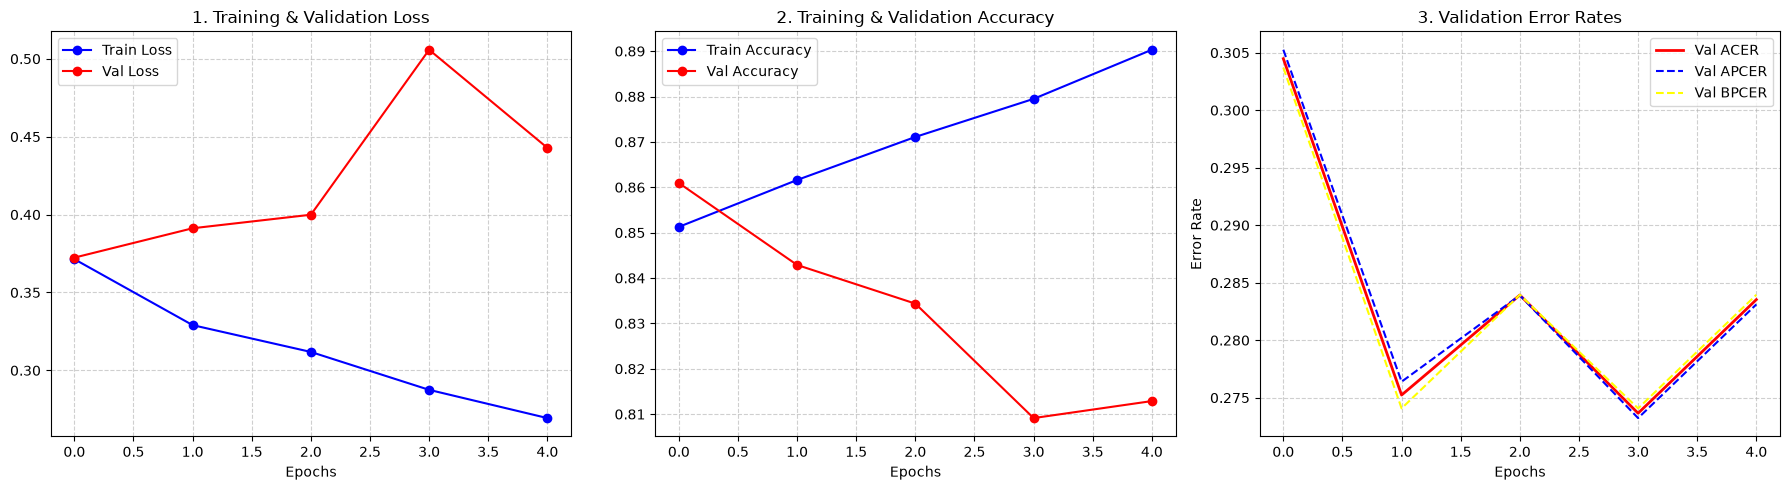

In [9]:
plot_training_history(history.history, output=OUTPUT_DIR + '/training_history.png')

In [10]:
y_val_prob = model.predict(val_ds)
y_val_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in val_ds], axis=0).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step


Đã lưu biểu đồ tại: ../outputs/baseline-model/evaluation_report.png


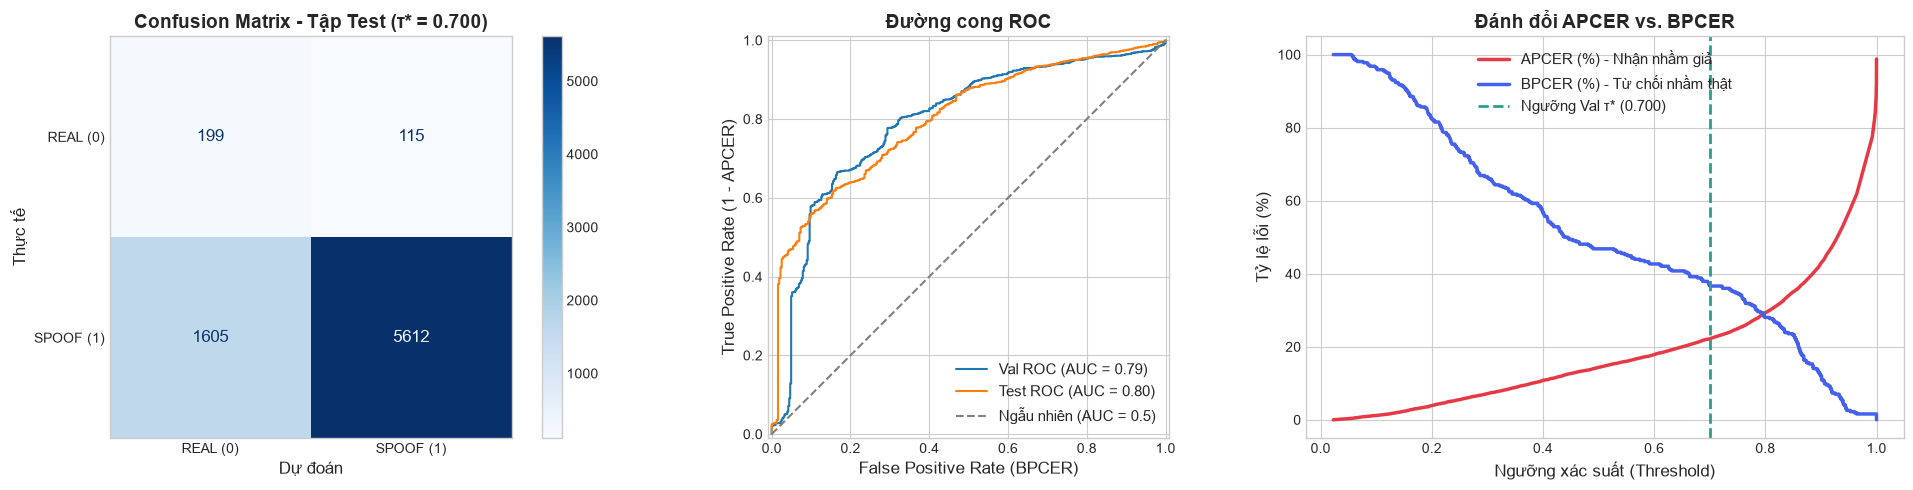

In [11]:
# Đánh giá và vẽ biểu đồ
y_test = (y_true, y_prob)
y_val = (y_val_true, y_val_prob)

evaluate_model(y_test, y_val, threshold_best, output=OUTPUT_DIR + '/evaluation_report.png')